In [ ]:
from importlib.metadata import version

print("torch version:", version("torch"))
print("tiktoken version:", version("tiktoken"))

Saved /home/apsaha/ai-scientist-lab/foundations/tokenization/tokenization_comparison.svg


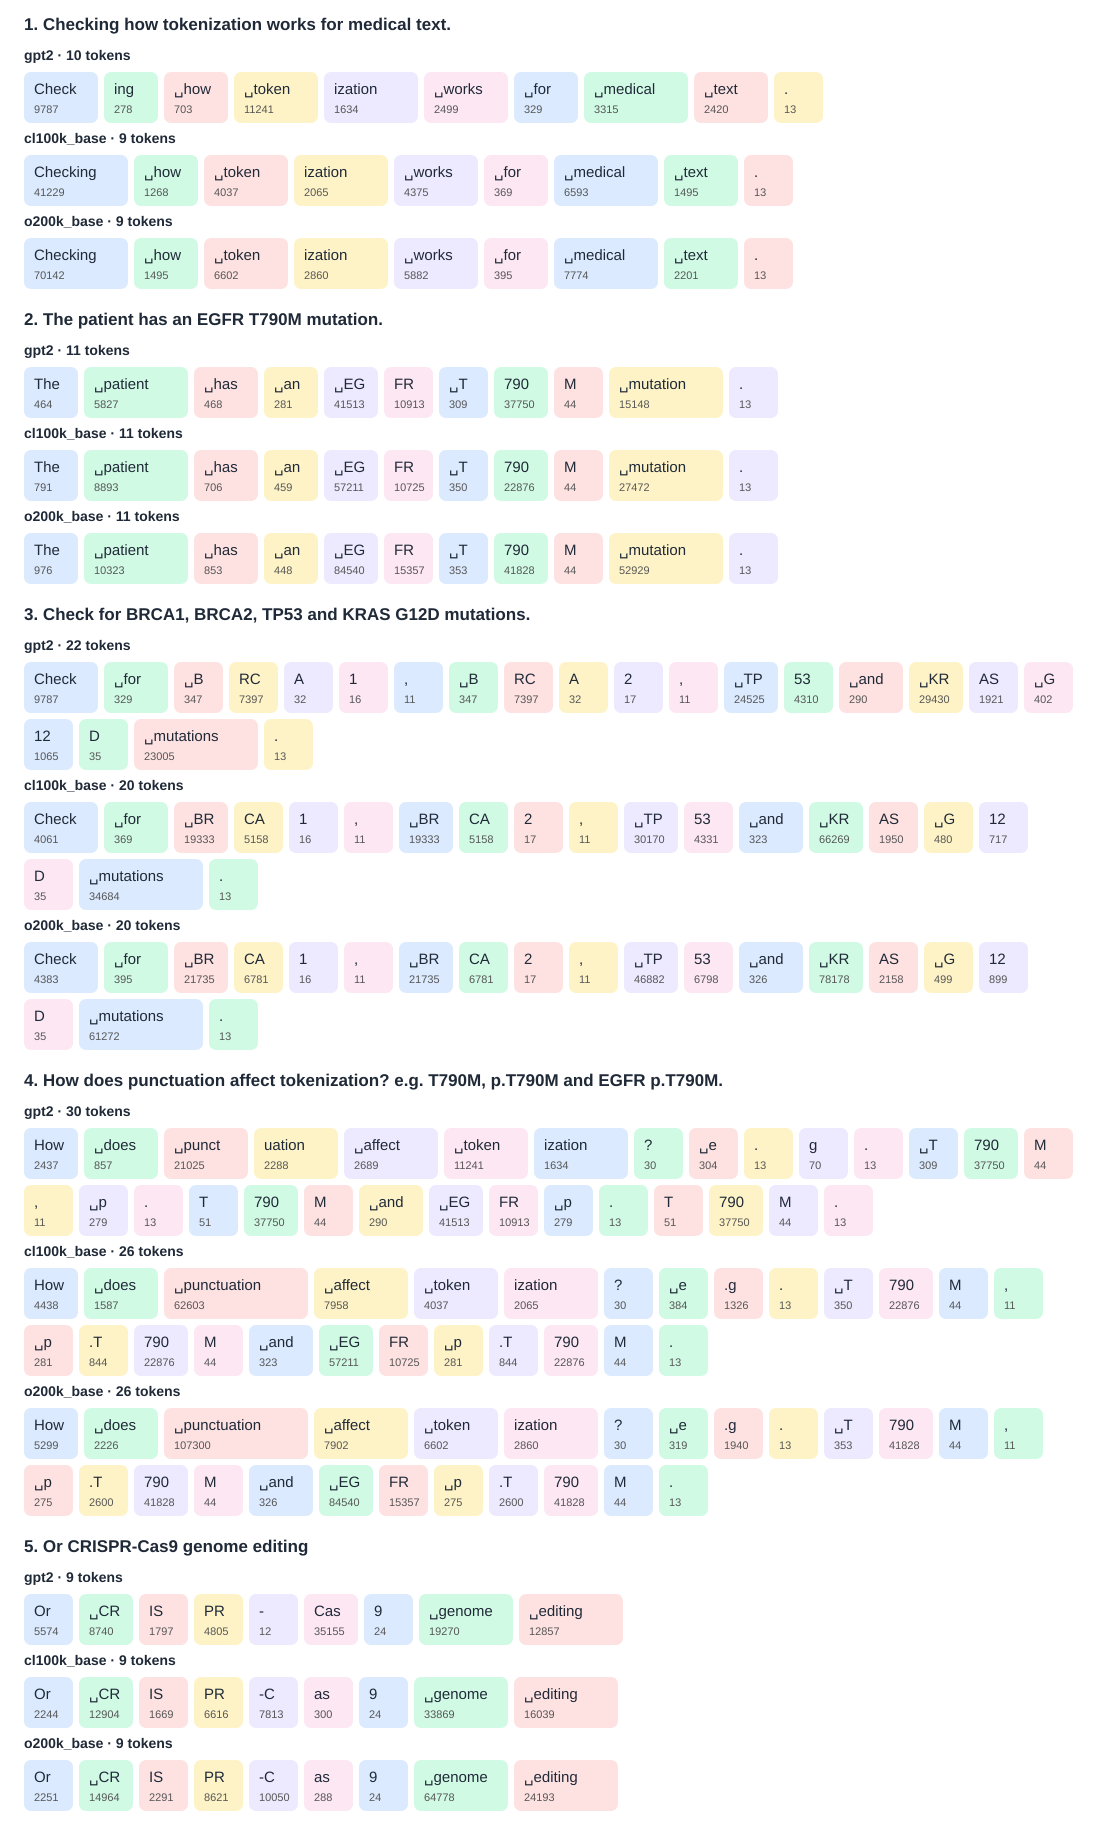

In [41]:
import html
from pathlib import Path

import tiktoken

tokenizers = {
    "gpt2": tiktoken.get_encoding("gpt2"),
    "cl100k_base": tiktoken.get_encoding("cl100k_base"),
    "o200k_base": tiktoken.get_encoding("o200k_base"),
}

texts = [
    "Checking how tokenization works for medical text.",
    "The patient has an EGFR T790M mutation.",
    "Check for BRCA1, BRCA2, TP53 and KRAS G12D mutations.",
    "How does punctuation affect tokenization? e.g. T790M, p.T790M and EGFR p.T790M.",
    "Or CRISPR-Cas9 genome editing",
]

COLORS = ["#DBEAFE", "#D1FAE5", "#FEE2E2", "#FEF3C7", "#EDE9FE", "#FCE7F3"]
SVG_WIDTH = 1100
LEFT = 24
RIGHT = 24
GAP = 6
BOX_HEIGHT = 51

parts = []
y = 30


def add_text(x, y, value, size=14, weight="normal", fill="#1F2937"):
    parts.append(
        f'<text x="{x}" y="{y}" font-family="Arial, sans-serif" '
        f'font-size="{size}" font-weight="{weight}" fill="{fill}">'
        f"{html.escape(str(value))}</text>"
    )


for text_number, text in enumerate(texts, start=1):
    add_text(LEFT, y, f"{text_number}. {text}", size=17, weight="bold")
    y += 30

    for name, tokenizer in tokenizers.items():
        token_ids = tokenizer.encode(text)
        add_text(LEFT, y, f"{name} · {len(token_ids)} tokens", weight="bold")
        y += 12

        x = LEFT
        for index, token_id in enumerate(token_ids):
            token_bytes = tokenizer.decode_single_token_bytes(token_id)

            # A token can contain only part of a UTF-8 character.
            # Show replacement characters for those rare cases.
            label = (
                token_bytes.decode("utf-8", errors="replace")
                .replace(" ", "␣")
                .replace("\n", "↵")
                .replace("\t", "⇥")
            )
            box_width = max(49, 24 + len(label) * 10)

            if x + box_width > SVG_WIDTH - RIGHT:
                x = LEFT
                y += BOX_HEIGHT + GAP

            parts.append(
                f'<rect x="{x}" y="{y}" width="{box_width}" '
                f'height="{BOX_HEIGHT}" rx="7" '
                f'fill="{COLORS[index % len(COLORS)]}"/>'
            )
            add_text(x + 10, y + 22, label, size=15)
            add_text(x + 10, y + 41, token_id, size=11, fill="#555555")
            x += box_width + GAP

        y += BOX_HEIGHT + 20

    y += 16

svg = (
    f'<svg xmlns="http://www.w3.org/2000/svg" '
    f'width="{SVG_WIDTH}" height="{y}" viewBox="0 0 {SVG_WIDTH} {y}">'
    f'<rect width="100%" height="100%" fill="white"/>'
    + "".join(parts)
    + "</svg>"
)

output = Path("tokenization_comparison.svg")
output.write_text(svg, encoding="utf-8")
print(f"Saved {output.resolve()}")

# Show it in your notebook too.
from IPython.display import SVG, display
display(SVG(filename=str(output)))